<a href="https://colab.research.google.com/github/evonyava/KSVD_Yakovliev_FIT_3-8/blob/main/%D0%9B%D0%912_1_%D0%9C%D0%9D_%D0%AF%D0%BA%D0%BE%D0%B2%D0%BB%D1%94%D0%B2_%D0%A4%D0%86%D0%A2_4_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2_1. Яковлєв, ФІТ 4-8

---



# Завдання 1

**Був присутній на парі**

Обробка та аналіз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

In [ ]:
# --- Імпорти та Завдання 1: Вивести перші 5 рядків датасета ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# Налаштовуємо виведення чисел: з роздіниками тисяч та без знаків після коми (щоб уникнути формату e+07)
pd.options.display.float_format = '{:,.0f}'.format

# Посилання на статтю
url = 'https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)'

# Додаємо User-Agent, щоб Вікіпедія думала, що ми заходимо з браузера
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

# Отримуємо HTML-код сторінки
response = requests.get(url, headers=headers)

# Зчитуємо таблиці з отриманого тексту (використовуємо StringIO для уникнення попереджень Pandas)
from io import StringIO
tables = pd.read_html(StringIO(response.text))

# Вибираємо потрібну таблицю (зазвичай це таблиця з індексом 2, але якщо виникне помилка, спробуйте 3)
df = tables[2]

print("1. Перші 5 рядків:")
display(df.head())

1. Перші 5 рядків:


,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


In [ ]:
# --- Завдання 2. Визначити розмір датасета ---
print("\n2. Розмір датасета (рядки, стовпці):", df.shape)


2. Розмір датасета (рядки, стовпці): (222, 4)


In [ ]:
# --- Завдання 3. Визначити оптимальну кількість стовпців ---
print("--- Завдання 3 ---")
# Перейменовуємо та залишаємо лише потрібні стовпці
if len(df.columns) == 4:
    df.columns = ['Country', 'IMF (2026)', 'World Bank (2025)', 'United Nations (2024)']
else:
    df = df.iloc[:, [0, 2, 4, 6]]
    df.columns = ['Country', 'IMF (2026)', 'World Bank (2025)', 'United Nations (2024)']

# Видаляємо рядок "World", якщо він є
if df.iloc[0, 0] == 'World':
    df = df.drop(df.index[0])

# Очищаємо назви країн від приміток у дужках (напр., "China[n 1]" -> "China")
df['Country'] = df['Country'].astype(str).str.replace(r'\[.*?\]', '', regex=True).str.strip()

# Робимо нумерацію з 1
df = df.reset_index(drop=True)
df.index = df.index + 1

display(df)

--- Завдання 3 ---


,Country,IMF (2026),World Bank (2025),United Nations (2024)
1,United States,32383920,30769700,29298000
2,China,20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
5,United Kingdom,4264794,4002588,3685881
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


In [ ]:
# --- Завдання 4. Заміна "—" на NaN, перевірка та заміна на середнє ---
print("\n--- Завдання 4 ---")
# Замінюємо тире на NaN
df = df.replace(["—", "-", "–", ""], np.nan)

print("Кількість пропущених значень до обробки:")
print(df.isnull().sum())

# Очищаємо дані від ком та перетворюємо у числа, заповнюємо пропуски середнім
for col in ['IMF (2026)', 'World Bank (2025)', 'United Nations (2024)']:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace(',', '', regex=True)
        df[col] = pd.to_numeric(df[col], errors='coerce')

    mean_val = df[col].mean()
    df[col] = df[col].fillna(mean_val)

print("\nПропущені значення замінено на середні показники по стовпцях.")


--- Завдання 4 ---
Кількість пропущених значень до обробки:
Country                  0
IMF (2026)               0
World Bank (2025)        0
United Nations (2024)    0
dtype: int64

Пропущені значення замінено на середні показники по стовпцях.


In [ ]:
# --- Завдання 5. Ще раз виводимо датасет ---
print("\n--- Завдання 5. Датасет після обробки пропусків ---")
display(df)


--- Завдання 5. Датасет після обробки пропусків ---


,Country,IMF (2026),World Bank (2025),United Nations (2024)
1,United States,"32,383,920","30,769,700","29,298,000"
2,China,"20,851,593","19,498,039","18,743,802"
3,Germany,"5,452,858","5,050,923","4,659,929"
4,Japan,"4,379,253","4,435,163","4,026,211"
5,United Kingdom,"4,264,794","4,002,588","3,685,881"
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,"661,460","626,050",81


In [ ]:
# --- Завдання 6. Перевірка та видалення дублікатів ---
print("\n--- Завдання 6 ---")
duplicates_count = df.duplicated().sum()
print(f"Знайдено дублікатів: {duplicates_count}")
if duplicates_count > 0:
    df = df.drop_duplicates()
    # Оновлюємо індекси після видалення
    df = df.reset_index(drop=True)
    df.index = df.index + 1
    print("Дублікати видалено.")


--- Завдання 6 ---
Знайдено дублікатів: 0


In [ ]:
# --- Завдання 7. Описова статистика ---
print("\n--- Завдання 7. Описова статистика ---")
display(df.describe())


--- Завдання 7. Описова статистика ---


,IMF (2026),World Bank (2025),United Nations (2024)
count,221,221,221
mean,"661,460","626,050","522,491"
std,"2,666,759","2,520,399","2,410,079"
min,65,57,56
25%,"18,959","19,928","8,840"
50%,"102,042","99,774","42,765"
75%,"661,460","626,050","298,697"
max,"32,383,920","30,769,700","29,298,000"


In [ ]:
# --- Завдання 8. Відхилення між IMF (2026) та World Bank (2025) ---
print("\n--- Завдання 8 ---")
df['Diff_IMF_WB'] = (df['IMF (2026)'] - df['World Bank (2025)']).abs()

max_diff_idx = df['Diff_IMF_WB'].idxmax()
country_max_diff = df.loc[max_diff_idx, 'Country']
max_diff_value = df.loc[max_diff_idx, 'Diff_IMF_WB']

print(f"Країна з найбільшою відмінністю між показниками IMF та World Bank: {country_max_diff}")
print(f"Абсолютна різниця становить: {max_diff_value:,.0f}")


--- Завдання 8 ---
Країна з найбільшою відмінністю між показниками IMF та World Bank: United States
Абсолютна різниця становить: 1,614,220


In [ ]:
# --- Завдання 9. Кореляція ---
print("\n--- Завдання 9. Матриця кореляції ---")
correlation_matrix = df[['IMF (2026)', 'World Bank (2025)', 'United Nations (2024)']].corr()

# Використовуємо .style.format, щоб вивести саме цю таблицю з 4 знаками після коми
display(correlation_matrix.style.format("{:.4f}"))


--- Завдання 9. Матриця кореляції ---


,IMF (2026),World Bank (2025),United Nations (2024)
IMF (2026),1.0000,0.9986,0.9973
World Bank (2025),0.9986,1.0000,0.9970
United Nations (2024),0.9973,0.9970,1.0000


In [ ]:
# --- Завдання 10. Середнє значення за стовпцями ---
print("\n--- Завдання 10. Середнє значення за стовпцями ---")
mean_values = df[['IMF (2026)', 'World Bank (2025)', 'United Nations (2024)']].mean()
print(mean_values)


--- Завдання 10. Середнє значення за стовпцями ---
IMF (2026)              661,460
World Bank (2025)       626,050
United Nations (2024)   522,491
dtype: float64


In [ ]:
# --- Завдання 11. Стандартне відхилення для кожної країни ---
print("\n--- Завдання 11 ---")
df['Std_Dev_Country'] = df[['IMF (2026)', 'World Bank (2025)', 'United Nations (2024)']].std(axis=1)

max_std_idx = df['Std_Dev_Country'].idxmax()
country_max_std = df.loc[max_std_idx, 'Country']
print(f"Країна з найвищою варіативністю у показниках: {country_max_std}")


--- Завдання 11 ---
Країна з найвищою варіативністю у показниках: United States


In [ ]:
# --- Завдання 12. Найвищі та найнижчі показники ---
print("\n--- Завдання 12. Найвищі та найнижчі показники ---")
for col in ['IMF (2026)', 'World Bank (2025)', 'United Nations (2024)']:
    max_country = df.loc[df[col].idxmax(), 'Country']
    min_country = df.loc[df[col].idxmin(), 'Country']
    print(f"{col}: Максимум -> {max_country} ({df[col].max():,.0f}), Мінімум -> {min_country} ({df[col].min():,.0f})")


--- Завдання 12. Найвищі та найнижчі показники ---
IMF (2026): Максимум -> United States (32,383,920), Мінімум -> Tuvalu (65)
World Bank (2025): Максимум -> United States (30,769,700), Мінімум -> Tuvalu (57)
United Nations (2024): Максимум -> United States (29,298,000), Мінімум -> Tuvalu (56)



--- Завдання 13. Гістограма та аналіз розподілу ---


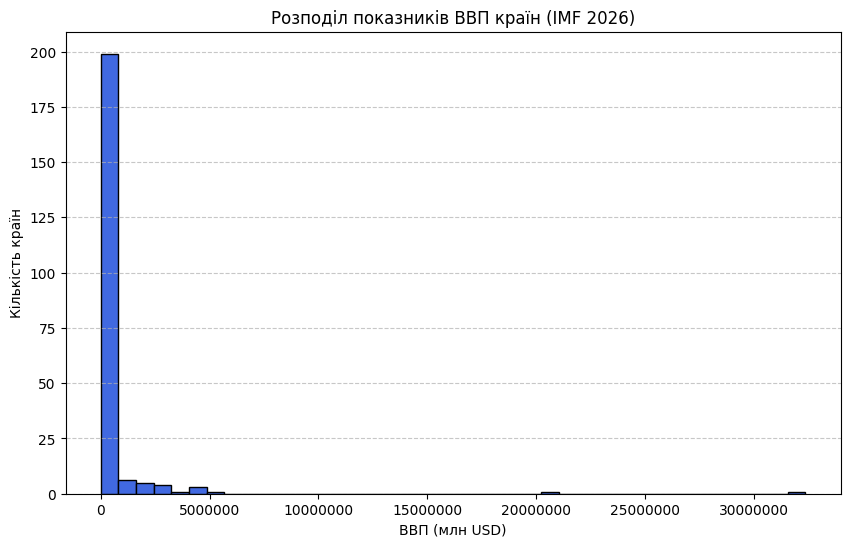


Відповідь на питання: 'Чи є країни, що виділяються?'
Так, розподіл є сильно асиметричним. Більшість країн мають відносно невеликий ВВП, але є кілька країн-гігантів, які формують довгий 'хвіст' далеко праворуч на графіку:


,Country,IMF (2026)
1,United States,"32,383,920"
2,China,"20,851,593"
3,Germany,"5,452,858"


In [ ]:
# --- Завдання 13. Гістограма для розподілу IMF (2026) ---
print("\n--- Завдання 13. Гістограма та аналіз розподілу ---")

plt.figure(figsize=(10, 6))
plt.hist(df['IMF (2026)'], bins=40, color='royalblue', edgecolor='black')
plt.title('Розподіл показників ВВП країн (IMF 2026)')
plt.xlabel('ВВП (млн USD)')
plt.ylabel('Кількість країн')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='x')
plt.show()

# Знаходимо країни, які є викидами
print("\nВідповідь на питання: 'Чи є країни, що виділяються?'")
print("Так, розподіл є сильно асиметричним. Більшість країн мають відносно невеликий ВВП, "
      "але є кілька країн-гігантів, які формують довгий 'хвіст' далеко праворуч на графіку:")

outliers = df.nlargest(3, 'IMF (2026)')
display(outliers[['Country', 'IMF (2026)']])

In [ ]:
# --- Завдання 14. Частка кожної країни ---
print("\n--- Завдання 14. Частка країн у загальному ВВП ---")
for col in ['IMF (2026)', 'World Bank (2025)', 'United Nations (2024)']:
    df[f'Share_{col} (%)'] = (df[col] / df[col].sum()) * 100

display(df[['Country', 'Share_IMF (2026) (%)', 'Share_World Bank (2025) (%)', 'Share_United Nations (2024) (%)']])


--- Завдання 14. Частка країн у загальному ВВП ---


,Country,Share_IMF (2026) (%),Share_World Bank (2025) (%),Share_United Nations (2024) (%)
1,United States,22,22,25
2,China,14,14,16
3,Germany,4,4,4
4,Japan,3,3,3
5,United Kingdom,3,3,3
...,...,...,...,...
217,Palau,0,0,0
218,Marshall Islands,0,0,0
219,Nauru,0,0,0
220,Montserrat,0,0,0


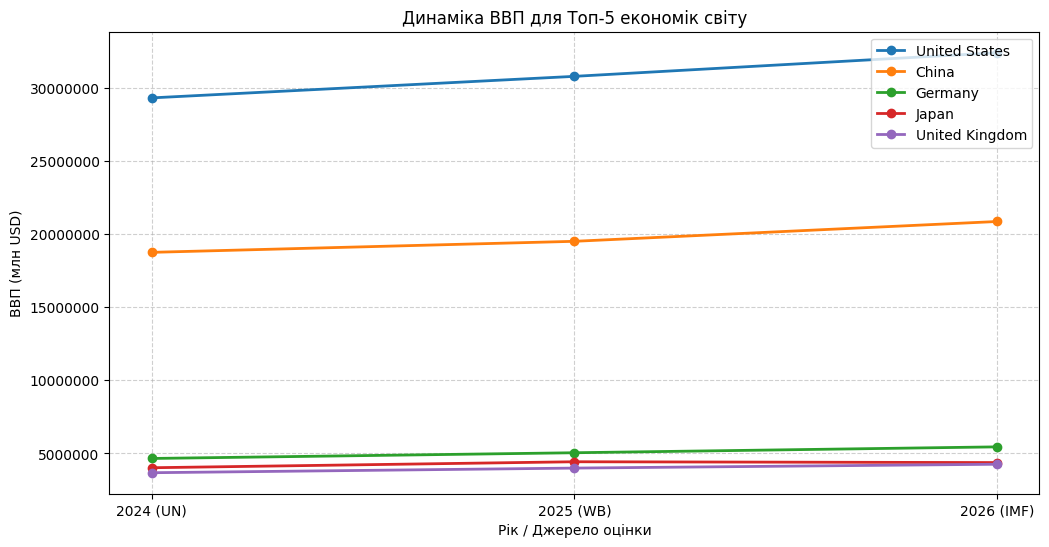

In [ ]:
# --- Завдання 15. Візуалізація змін у показниках для Топ-5 країн ---
top_5_countries = df.nlargest(5, 'IMF (2026)')
years = ['2024 (UN)', '2025 (WB)', '2026 (IMF)']
columns_to_plot = ['United Nations (2024)', 'World Bank (2025)', 'IMF (2026)']

plt.figure(figsize=(12, 6))
for index, row in top_5_countries.iterrows():
    plt.plot(years, row[columns_to_plot], marker='o', linewidth=2, label=row['Country'])

plt.title('Динаміка ВВП для Топ-5 економік світу')
plt.xlabel('Рік / Джерело оцінки')
plt.ylabel('ВВП (млн USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.ticklabel_format(style='plain', axis='y') # Вимикаємо науковий формат на осі Y
plt.show()